# Fundamentals of Neural Networks

In [344]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [345]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
sns.set_style("whitegrid")


## Introduction to Fundamentals of Neural Networks

So far in this course we've used models like linear/logistic regression, clustering, and PCA. Those models work well, but they share a limitation: they can only learn relationships that are (roughly) linear combinations of the input features, or that we've explicitly engineered (e.g. polynomial terms).

**Neural networks** remove that limitation. A neural network is a function made of many small, simple pieces - artificial "neurons" - stacked in layers and connected together. Individually, each neuron is barely more than a weighted sum plus a nonlinear twist. Stacked together, though, a network can approximate extremely complex, non-linear relationships between inputs and outputs, which is why they power everything from image recognition to language models.

##  Neural Network Architecture

A neural network's **architecture** is its blueprint: how many layers it has, how many neurons are in each layer, how those neurons are connected, and which activation function each layer uses. Get the architecture right, and the network has the *capacity* to learn the pattern in your data. Get it wrong (too small, too large, wrong activations), and it will underfit, overfit, or fail to train at all.

Every feedforward neural network is built from the same three ingredients, repeated and stacked:

1. **Neurons** - the basic computational unit
2. **Layers** - groups of neurons (input, hidden, output)
3. **Activation functions** - the nonlinearity applied inside each neuron




**A single neuron** takes a vector of inputs $x = [x_1, x_2, ..., x_n]$, multiplies each by a learned **weight** $w_i$, sums them with a learned **bias** $b$, and passes the result through an **activation function** $f$:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = w \cdot x + b$$
$$a = f(z)$$

- **Weights** control how much influence each input has, and are what the network actually learns.
- **Bias** shifts the neuron's output, letting it fit data that doesn't pass through the origin.
- **Activation function** introduces non-linearity — without it, stacking layers would be pointless (see Section 1).

**Layers** are just neurons grouped together:

- **Input layer** — not really neurons, just the raw features. Its size is fixed by your data (number of columns).
- **Hidden layer(s)** — the layers that do the actual representation learning. Depth (more layers) and width (more neurons per layer) both increase the network's capacity.
- **Output layer** — produces the prediction. Its size and activation depend on the task (see table below).

| Task | Output neurons | Output activation |
|---|---|---|
| Binary classification | 1 | Sigmoid |
| Multi-class classification (K classes) | K | Softmax |
| Regression | 1 (or more) | Linear (none) |

common activation functions.

In [346]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [347]:
sigmoid(-1)

np.float64(0.2689414213699951)

In [348]:
def tanh(z):
    return np.tanh(z)

In [349]:
tanh(-10)

np.float64(-0.9999999958776927)

In [350]:
def relu(z):
    return np.maximum(0, z)

In [351]:
relu(-2)

np.int64(0)

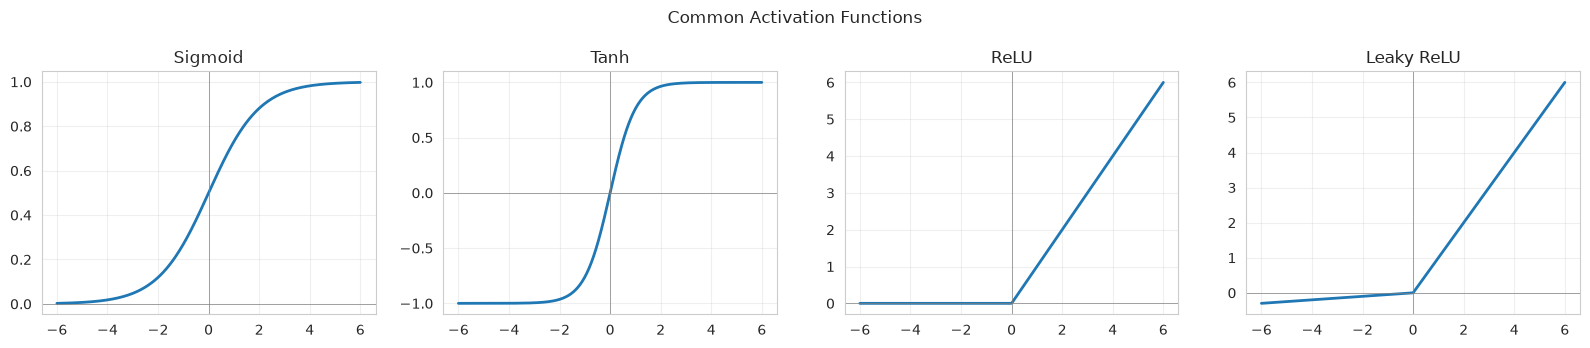

In [352]:

def leaky_relu(z, alpha=0.05):
    return np.where(z > 0, z, alpha * z)

z = np.linspace(-6, 6, 400)
activations = {
    "Sigmoid": sigmoid(z),
    "Tanh": tanh(z),
    "ReLU": relu(z),
    "Leaky ReLU": leaky_relu(z),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharex=True, sharey=False)
for ax, (name, values) in zip(axes, activations.items()):
    ax.plot(z, values, linewidth=2)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.suptitle("Common Activation Functions")
plt.tight_layout()
plt.show()


- **Sigmoid** squashes any input into $(0, 1)$ — ideal for a binary output layer, but saturates (near-zero gradient) for large $|z|$, which slows learning in hidden layers

In [353]:
leaky_relu(-100)

array(-5.)

.
- **Tanh** is a rescaled sigmoid squashing to $(-1, 1)$, zero-centered — generally learns faster than sigmoid in hidden layers, but still saturates.

In [354]:
#


- **ReLU** ($\max(0, z)$) is the default choice for hidden layers in modern networks: cheap to compute and doesn't saturate for positive inputs, though neurons can "die" (get stuck outputting 0) if $z$ stays negative.

In [355]:
#

- **Leaky ReLU** fixes the dying-neuron problem by allowing a small negative slope.

In [356]:
#

### Example: Neural Network Architecture

Let's put this architecture together in code and run a **forward pass** - pushing data through the network - *before* any training happens. This shows what the architecture computes on its own, and sets up why we need training

We'll use `make_moons`, a synthetic 2D dataset with two interleaving, non-linearly-separable classes - a good stress test for whether a network's non-linearity is doing anything.

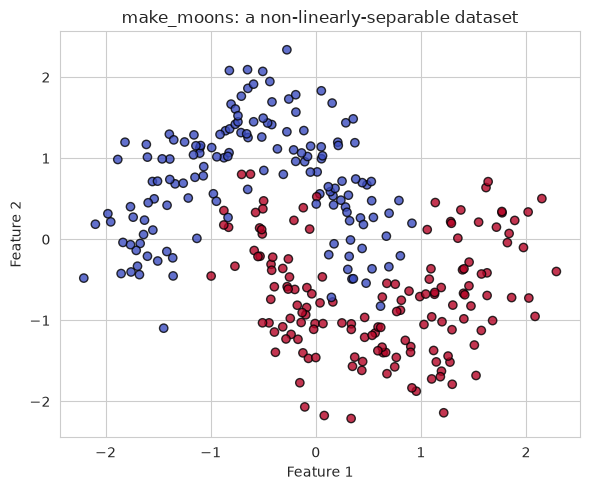

In [357]:
X, y = make_moons(n_samples=300, noise=0.20, random_state=42)
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", alpha=0.8)
plt.title("make_moons: a non-linearly-separable dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()


In [358]:
# Architecture: 2 inputs -> (4 hidden neurons (tanh))->(one layer) -> 1 output neuron (sigmoid)
n_input, n_hidden, n_output = 2, 4, 1

# Random initialization only -- no training has happened yet, so these
# weights/biases encode nothing about the data 
rng = np.random.default_rng(42)
W1 = rng.normal(0, 1, size=(n_input, n_hidden))   # input -> hidden weights
b1 = np.zeros((1, n_hidden))                      # hidden layer biases
W2 = rng.normal(0, 1, size=(n_hidden, n_output))  # hidden -> output(Section 2.4, step 6) weights
b2 = np.zeros((1, n_output))                      # output layer bias

def forward_pass(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1     # weighted sum into the hidden layer
    A1 = tanh(Z1)        # hidden layer activation (adds non-linearity)
    Z2 = A1 @ W2 + b2    # weighted sum into the output layer
    A2 = sigmoid(Z2)     # output activation -> probability in (0, 1)
    return A2



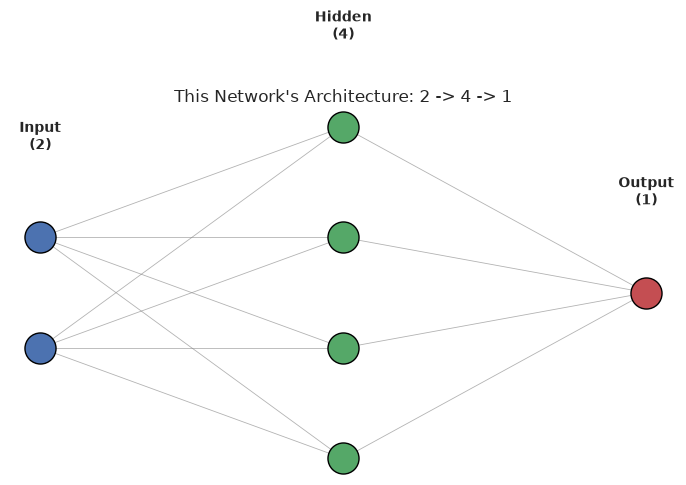

In [359]:
# Draw this network's architecture: n_input -> n_hidden -> n_output
def draw_network(layer_sizes, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    v_spacing = 1.0
    h_spacing = 2.0
    layer_x = [i * h_spacing for i in range(len(layer_sizes))]

    # Stack each layer's neurons vertically, centered on y = 0
    positions = []
    for x, n_neurons in zip(layer_x, layer_sizes):
        layer_top = v_spacing * (n_neurons - 1) / 2
        positions.append([(x, layer_top - i * v_spacing) for i in range(n_neurons)])

    # Draw every connection first, so neuron markers sit on top
    for layer_pos, next_layer_pos in zip(positions[:-1], positions[1:]):
        for (x1, y1) in layer_pos:
            for (x2, y2) in next_layer_pos:
                ax.plot([x1, x2], [y1, y2], color="grey", linewidth=0.6, alpha=0.6, zorder=1)

    labels = ["Input"] + ["Hidden"] * (len(layer_sizes) - 2) + ["Output"]
    colors = ["#4C72B0", "#55A868", "#C44E52"]
    color_map = [colors[0]] + [colors[1]] * (len(layer_sizes) - 2) + [colors[2]]

    for layer_pos, color, label, x in zip(positions, color_map, labels, layer_x):
        for (px, py) in layer_pos:
            ax.scatter(px, py, s=500, color=color, edgecolor="black", zorder=2)
        ax.text(x, max(p[1] for p in layer_pos) + 0.8, f"{label}\n({len(layer_pos)})",
                ha="center", fontsize=10, fontweight="bold")

    ax.axis("off")
    return ax

draw_network([n_input, n_hidden, n_output])
plt.title(f"This Network's Architecture: {n_input} -> {n_hidden} -> {n_output}")
plt.tight_layout()
plt.show()


### Process: Neural Network Architecture

Designing an architecture is a step-by-step decision process:

1. **Fix the input layer size** to the number of features in your data (no choice here — it's determined by the dataset).
2. **Choose the output layer size and activation** based on the task (binary/multi-class/regression).
3. **Choose the number of hidden layers ("depth")** - more layers let the network represent more complex, hierarchical patterns, at the cost of being harder to train and more prone to overfitting.
4. **Choose the number of neurons per hidden layer ("width")** - more neurons increase capacity to fit complex boundaries, but also increase the risk of overfitting and the compute cost.
5. **Choose an activation function for each hidden layer** - ReLU (or a variant) is the standard default; sigmoid/tanh are used more selectively today (small networks, specific gating uses).
6. **Initialize the weights** - small random values (never all zeros, or every neuron in a layer would learn the same thing - a failure mode called symmetry).

A useful sanity check at each step is counting the number of learnable parameters, since that's a rough proxy for how much data the network will need to train without overfitting.

In [360]:
def describe_architecture(layer_sizes):
    print(f"{'Layer':<12}{'Neurons':<10}{'Params (W + b)':<18}")
    total_params = 0
    for i in range(1, len(layer_sizes)):
        n_in, n_out = layer_sizes[i - 1], layer_sizes[i]
        n_params = n_in * n_out + n_out
        total_params += n_params
        layer_name = "Output" if i == len(layer_sizes) - 1 else f"Hidden {i}"
        print(f"{layer_name:<12}{n_out:<10}{n_params:<18}")
    print(f"\nTotal learnable parameters: {total_params}")

describe_architecture([2, 8,8, 1])


Layer       Neurons   Params (W + b)    
Hidden 1    8         24                
Hidden 2    8         72                
Output      1         9                 

Total learnable parameters: 105


In [361]:
untrained_probs = forward_pass(X, W1, b1, W2, b2)
untrained_preds = (untrained_probs >= 0.5).astype(int).ravel()  # threshold probabilities into class labels

print(f"Architecture: {n_input} -> {n_hidden} -> {n_output}")
print(f"Untrained accuracy: {accuracy_score(y, untrained_preds):.3f}  (chance level is ~0.5)")

Architecture: 2 -> 4 -> 1
Untrained accuracy: 0.543  (chance level is ~0.5)


With **random, untrained weights**, the network's architecture alone gives us roughly chance-level accuracy — the shape of the network gives it the *capacity* to separate the moons, but right now the weights don't encode anything meaningful about this data. That's the job of training, which is exactly what Day 3 (backpropagation and gradient descent) covers.


## Back Propagation and Gradient Descent

### Introduction to Back Propagation and Gradient Descent

We had a network architecture with *random* weights, and it performed at chance level. **Training** is the process of adjusting those weights and biases so the network's predictions get closer to the true labels.

This happens in two parts, repeated over and over:

- **Gradient descent** - the general optimization algorithm: to minimize a loss function, repeatedly take a small step in the direction that decreases it fastest (the negative gradient).
- **Backpropagation** - the specific, efficient algorithm for computing *how much each weight in a multi-layer network contributed to the error*, working backward from the output layer to the input layer.

Backpropagation doesn't do the learning itself - it just computes gradients efficiently. Gradient descent is what actually uses those gradients to update the weights.

### Defining Back Propagation and Gradient Descent

**Gradient descent** minimizes a loss function $L(\theta)$ over parameters $\theta$ by repeating:

$$\theta \leftarrow \theta - \eta \, \nabla_\theta L(\theta)$$

where $\eta$ (eta) is the **learning rate** - how big a step to take - and $\nabla_\theta L$ is the gradient: the direction of steepest *increase*, so we step in the opposite direction.

Let's visualize this on a simple 2D bowl-shaped loss surface, $L(x, y) = x^2 + y^2$, where we can see the whole loss landscape and watch the parameters converge to the minimum.

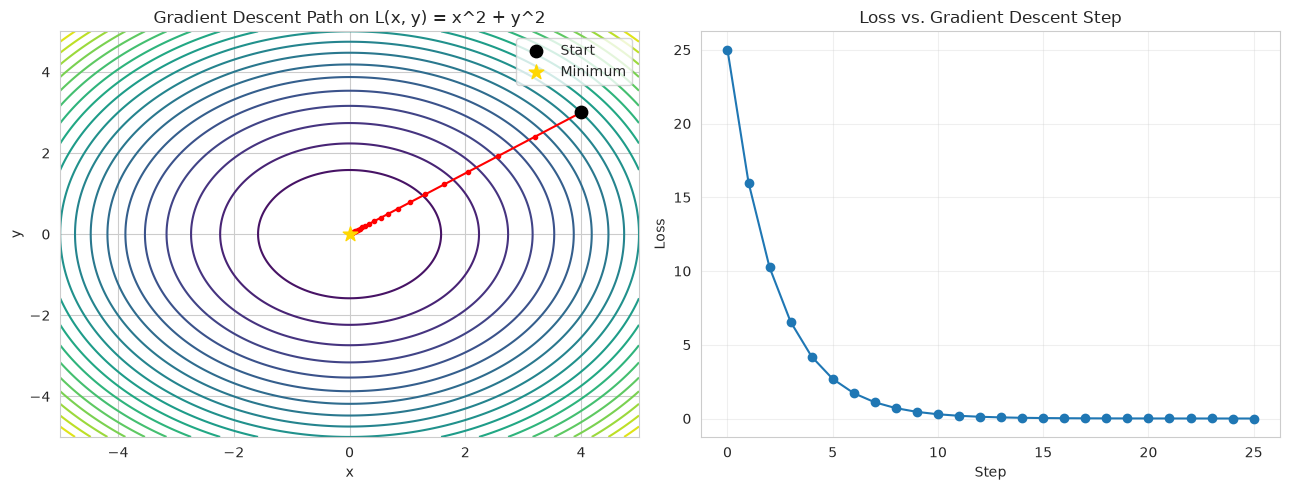

Converged to (x, y) = (0.0151, 0.0113) after 25 steps


In [362]:
def loss_fn(x, y):
    return x**2 + y**2   # the "loss surface" we're minimizing -- a simple bowl shape

def grad_fn(x, y):
    return np.array([2 * x, 2 * y])   # gradient of loss_fn: partial derivatives w.r.t. x and y

# Gradient descent from a starting point
theta = np.array([4.0, 3.0])   # starting (x, y) -- deliberately far from the minimum at (0, 0)
learning_rate = 0.1            # eta: how big a step to take against the gradient each iteration
n_steps = 25

path = [theta.copy()]          # record every position visited, for plotting the descent path
for step in range(n_steps):
    grad = grad_fn(*theta)               # direction of steepest increase at the current point
    theta = theta - learning_rate * grad  # step against the gradient -> theta <- theta - eta * grad
    path.append(theta.copy())

path = np.array(path)

# Plot the loss surface (contours) and the descent path
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
zz = loss_fn(xx, yy)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: the path taken through (x, y) space, overlaid on contour lines of the loss surface
axes[0].contour(xx, yy, zz, levels=20, cmap="viridis")
axes[0].plot(path[:, 0], path[:, 1], marker="o", color="red", markersize=3, linewidth=1.5)
axes[0].scatter(*path[0], color="black", s=80, label="Start", zorder=5)
axes[0].scatter(0, 0, color="gold", s=120, marker="*", label="Minimum", zorder=5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Gradient Descent Path on L(x, y) = x^2 + y^2")
axes[0].legend()

# Right plot: the loss value at each step, confirming it decreases monotonically
axes[1].plot([loss_fn(*p) for p in path], marker="o")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss vs. Gradient Descent Step")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Converged to (x, y) = ({path[-1][0]:.4f}, {path[-1][1]:.4f}) after {n_steps} steps")

Every step moves directly against the gradient, so the path always points toward locally decreasing loss - and on this simple bowl-shaped (convex) surface, that reliably converges to the true minimum at $(0, 0)$. A neural network's loss surface is far higher-dimensional and not convex, but the update rule is exactly the same.

**The learning rate matters a lot.** Too small, and training crawls; too large, and the steps overshoot the minimum and can diverge entirely.

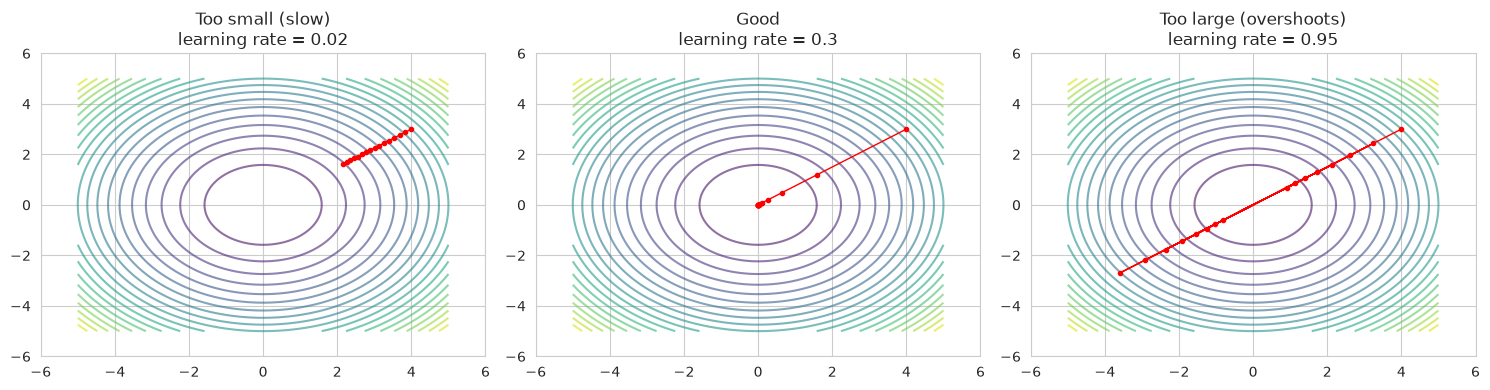

In [363]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rates = [0.02, 0.3, 0.95]
titles = ["Too small (slow)", "Good", "Too large (overshoots)"]

for ax, lr, title in zip(axes, rates, titles):
    theta = np.array([4.0, 3.0])
    path = [theta.copy()]
    for _ in range(15):
        grad = grad_fn(*theta)
        theta = theta - lr * grad
        path.append(theta.copy())
    path = np.array(path)

    ax.contour(xx, yy, zz, levels=20, cmap="viridis", alpha=0.6)
    ax.plot(path[:, 0], path[:, 1], marker="o", color="red", markersize=3, linewidth=1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_title(f"{title}\nlearning rate = {lr}")

plt.tight_layout()
plt.show()


### Example: Back Propagation and Gradient Descent

Now let's see backpropagation itself, worked out by hand on the smallest possible network: **one input, one neuron, one output**, trained on a single example, using the chain rule to compute exactly how the loss changes with respect to the weight and bias.

Network: $\hat{y} = \sigma(wx + b)$, loss: $L = \frac{1}{2}(\hat{y} - y)^2$

In [364]:
x, y_true = 2.0, 1.0     # a single training example
w, b = 0.5, 0.0          # initial weight and bias
learning_rate = 0.5

print(f"{'Iter':<6}{'z':<9}{'y_hat':<9}{'Loss':<9}{'dL/dw':<10}{'dL/db':<10}{'w (new)':<10}{'b (new)':<10}")
for i in range(6):
    # Forward pass: z = w*x + b, y_hat = sigmoid(z)
    z = w * x + b
    y_hat = sigmoid(z)
    loss = 0.5 * (y_hat - y_true) ** 2   # squared error between prediction and true label

    # Backward pass: chain rule, one factor per link between the loss and w (or b)
    dL_dyhat = (y_hat - y_true)          # dL/dy_hat: how loss changes with the prediction
    dyhat_dz = y_hat * (1 - y_hat)       # dy_hat/dz: derivative of sigmoid
    dz_dw, dz_db = x, 1                  # dz/dw = x, dz/db = 1

    dL_dw = dL_dyhat * dyhat_dz * dz_dw  # chain rule product -> gradient w.r.t. w
    dL_db = dL_dyhat * dyhat_dz * dz_db  # chain rule product -> gradient w.r.t. b

    # Gradient descent update: move w and b against their gradients
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    print(f"{i:<6}{z:<9.4f}{y_hat:<9.4f}{loss:<9.4f}{dL_dw:<10.4f}{dL_db:<10.4f}{w:<10.4f}{b:<10.4f}")

Iter  z        y_hat    Loss     dL/dw     dL/db     w (new)   b (new)   
0     1.0000   0.7311   0.0362   -0.1058   -0.0529   0.5529    0.0264    
1     1.1322   0.7562   0.0297   -0.0899   -0.0449   0.5978    0.0489    
2     1.2445   0.7764   0.0250   -0.0777   -0.0388   0.6366    0.0683    
3     1.3416   0.7928   0.0215   -0.0681   -0.0340   0.6707    0.0853    
4     1.4267   0.8064   0.0187   -0.0605   -0.0302   0.7009    0.1005    
5     1.5023   0.8179   0.0166   -0.0542   -0.0271   0.7280    0.1140    


Each iteration, the loss shrinks and $\hat{y}$ creeps closer to the true label $y=1$. This *is* backpropagation and gradient decent



### Process: Back Propagation and Gradient Descent

Training a neural network repeats four steps every iteration:

1. **Forward pass** — push a batch of inputs through the network layer by layer, caching each layer's output (needed later for the backward pass).
2. **Compute the loss** — compare the network's final output to the true labels using a loss function (e.g. binary cross-entropy for classification, MSE for regression).
3. **Backward pass (backpropagation)** — starting from the loss, use the chain rule to compute the gradient of the loss with respect to *every* weight and bias, working from the output layer back to the input layer. Each layer only needs the gradient flowing in from the layer after it, plus its own cached forward values — this reuse is what makes backprop efficient instead of recomputing everything from scratch for each parameter.
4. **Update the weights** — apply the gradient descent update rule ($\theta \leftarrow \theta - \eta \nabla L$) to every weight and bias using the gradients just computed.

Repeating steps 1–4 over the whole training set is one **epoch**. Networks are typically trained for many epochs until the loss stops meaningfully improving.

### A neural network class from scratch

This implements a network with **one hidden layer** (`tanh` activation) and a **sigmoid output** for binary classification - the same architecture we forward-passed i now with a working `fit()` method implementing the training loop 

In [365]:
class NeuralNetwork:
    def __init__(self, n_input, n_hidden, n_output=1, learning_rate=0.5, seed=42):
        rng = np.random.default_rng(seed)
        # Small random init (scaled by fan-in) avoids symmetry and saturated activations
        self.W1 = rng.normal(0, 1, size=(n_input, n_hidden)) * np.sqrt(1 / n_input)  # input -> hidden weights
        self.b1 = np.zeros((1, n_hidden))                                            # hidden biases
        self.W2 = rng.normal(0, 1, size=(n_hidden, n_output)) * np.sqrt(1 / n_hidden)  # hidden -> output weights
        self.b2 = np.zeros((1, n_output))                                            # output bias
        self.lr = learning_rate                                                      # eta, the gradient descent step size

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # Cache Z1/A1/Z2/A2 on self -- backward() reuses them instead of recomputing (Section 3.4)
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = np.tanh(self.Z1)                 # hidden activation
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self._sigmoid(self.Z2)            # output activation
        return self.A2

    def compute_loss(self, y_pred, y_true):
        # Binary cross-entropy: penalizes confident wrong predictions much more than uncertain ones
        y_true = y_true.reshape(-1, 1)
        eps = 1e-9   # avoid log(0)
        return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

    def backward(self, X, y_true):
        m = X.shape[0]   # batch size -- gradients are averaged over the batch, not summed
        y_true = y_true.reshape(-1, 1)

        # Output layer gradients (cross-entropy + sigmoid simplifies to A2 - y)
        dZ2 = self.A2 - y_true
        dW2 = self.A1.T @ dZ2 / m
        db2 = dZ2.sum(axis=0, keepdims=True) / m

        # Hidden layer gradients (chain rule through tanh): propagate dZ2 back through W2, then through tanh's derivative
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * (1 - self.A1 ** 2)
        dW1 = X.T @ dZ1 / m
        db1 = dZ1.sum(axis=0, keepdims=True) / m

        # Gradient descent update: theta <- theta - eta * gradient, applied to every weight/bias
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=3000, verbose_every=500):
        # The training loop from Section 3.4: forward pass -> loss -> backward pass -> update, repeated per epoch
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y_pred, y)
            losses.append(loss)
            self.backward(X, y)
            if verbose_every and epoch % verbose_every == 0:
                print(f"Epoch {epoch:5d} | Loss: {loss:.4f}")
        return losses

    def predict(self, X, threshold=0.5):
        # Forward pass gives a probability; threshold it into a hard 0/1 class label
        return (self.forward(X) >= threshold).astype(int).ravel()

### Training on `make_moons`

We can now finish what Section 2.3 started: train the network for real and compare against the untrained, random-weight baseline.

In [366]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

nn = NeuralNetwork(n_input=2, n_hidden=8, learning_rate=0.5, seed=42)
losses = nn.fit(X_train, y_train, epochs=1000, verbose_every=500)

train_acc = accuracy_score(y_train, nn.predict(X_train))
test_acc = accuracy_score(y_test, nn.predict(X_test))
print(f"\nTrain accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}  (untrained baseline was ~0.5, Section 2.3)")


Epoch     0 | Loss: 0.7017
Epoch   500 | Loss: 0.1476

Train accuracy: 0.964
Test accuracy:  0.947  (untrained baseline was ~0.5, Section 2.3)


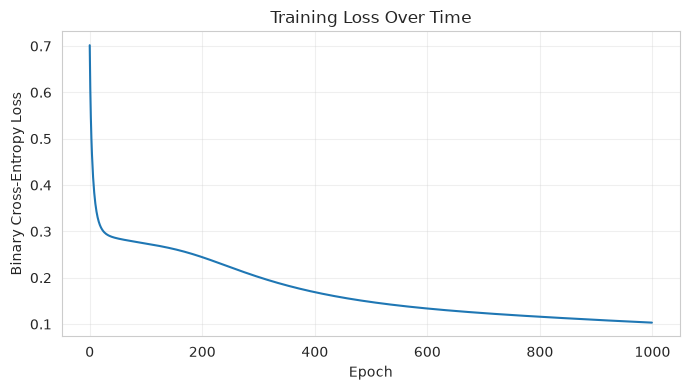

In [367]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Over Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


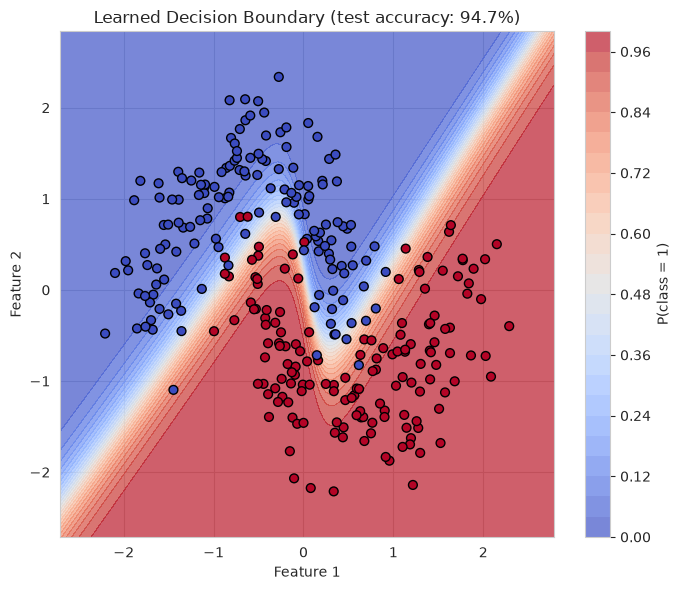

In [368]:
# Visualize the learned decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = nn.forward(grid).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, probs, levels=25, cmap="coolwarm", alpha=0.7)
plt.colorbar(label="P(class = 1)")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=40)
plt.title(f"Learned Decision Boundary (test accuracy: {test_acc:.1%})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()


### comparing to `scikit-learn`

In [369]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation="tanh",
    solver="sgd",
    learning_rate_init=0.5,
    max_iter=3000,
    random_state=42,
)
mlp.fit(X_train, y_train)
mlp_test_acc = accuracy_score(y_test, mlp.predict(X_test))

print(f"From-scratch NeuralNetwork test accuracy: {test_acc:.3f}")
print(f"scikit-learn MLPClassifier test accuracy:  {mlp_test_acc:.3f}")


From-scratch NeuralNetwork test accuracy: 0.947
scikit-learn MLPClassifier test accuracy:  0.933


### comparing to `TensorFlow`

In [370]:
# imports 
import tensorflow as tf

tf.random.set_seed(42)

In [371]:
from tensorflow.keras.layers import Input,Dense

In [372]:
model = tf.keras.Sequential([
    Input(shape=(2,)),
    Dense(8,activation="tanh"),
    # Dense(32,activation="relu"),
    # Dense(64,activation="leaky_relu")
    Dense(1,activation="sigmoid")
])

In [373]:
# model architecture 
tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation="tanh"),  # same 2 -> 8 hidden layer as the from-scratch net
    tf.keras.layers.Dense(1, activation="sigmoid"),                  # binary output
])

In [374]:
# compile the model

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

tf_model.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [375]:
# fit the model

tf_history = tf_model.fit(X_train, y_train, epochs=1000, verbose=0)
tf_test_acc = tf_model.evaluate(X_test, y_test, verbose=0)[1]


In [376]:
print(f"From-scratch NeuralNetwork test accuracy: {test_acc:.3f}")
print(f"scikit-learn MLPClassifier test accuracy:  {mlp_test_acc:.3f}")
print(f"TensorFlow/Keras test accuracy:             {tf_test_acc:.3f}")

From-scratch NeuralNetwork test accuracy: 0.947
scikit-learn MLPClassifier test accuracy:  0.933
TensorFlow/Keras test accuracy:             0.893
